# Mô phỏng ĐẦU–CUỐI: dự đoán giá → chấp nhận → giá cuối → đối chiếu thực tế

Notebook này **nối toàn bộ hệ thống** lại và chạy trên **864.360 chuyến** của tập test.

```
① Model giá (đã train)      →  p̂  = giá đối thủ dự đoán
② Acceptance model          →  P(khách chấp nhận | giá mình, p̂, bối cảnh)
③ Tối ưu                    →  p* = giá mình NÊN báo
④ Đối chiếu                 →  p* lệch bao nhiêu so với giá thật khách đã trả?
```

---

## ⚠️ Đọc kỹ trước khi xem kết quả — 2 điều dễ hiểu nhầm

**(1) `p*` KHÔNG phải dự đoán giá — nó là giá KHUYẾN NGHỊ.**

Độ lệch giữa `p*` và giá thật **không phải sai số model**. Nó là **khoảng cách chiến lược có chủ ý**:
model nói *"nên bán rẻ hơn đối thủ để giành khách"*. Lệch càng nhiều không có nghĩa càng sai.

**(2) Khách so giá mình với giá đối thủ THẬT, không phải giá mình dự đoán.**

Đây là điểm mấu chốt của mô phỏng:

| | Dùng giá nào |
|---|---|
| Lúc **quyết định** báo giá | `p̂` — dự đoán (vì chưa biết giá thật) |
| Lúc khách **cân nhắc** chấp nhận | `p_thật` — giá đối thủ thật sự |

Chính sự chênh lệch này tạo ra **chi phí của việc dự đoán sai** — và mô phỏng sẽ định lượng được nó.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ---------- Tham so acceptance model ----------
P0 = 0.5           # muc chap nhan nen khi gia ngang bang doi thu   (GIA DINH)
EPS = -2.0         # firm-level elasticity                          (GIA DINH)
EPS_DAI = [-1.2, -2.0, -3.0]

def P_accept(ty_le, eps=EPS, P0=P0, dich=0.0):
    b = eps / (1 - P0)
    a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le) - np.log1p(dich)))))

# ---------- Ty le gia toi uu (khong phu thuoc p_ref hay dich WTP) ----------
def ty_le_toi_uu(eps=EPS, P0=P0):
    rr = np.linspace(0.40, 1.60, 4000)
    return rr[int(np.argmax(rr * P_accept(rr, eps, P0)))]

R_STAR = ty_le_toi_uu()
print(f"Ty le gia toi uu (tai boi canh trung tinh): {R_STAR:.4f}x gia doi thu")
print(f"  -> gia nen bao = {R_STAR:.3f} x (1 + dich_WTP) x p_doi_thu")

Ty le gia toi uu (tai boi canh trung tinh): 0.7598x gia doi thu
  -> gia nen bao = 0.760 x (1 + dich_WTP) x p_doi_thu


## 1. Nạp dự đoán từ model giá & ghép bối cảnh

In [2]:
ALGO = "HistGB"

# --- Du doan tu model gia (Hybrid) ---
ar = pd.read_parquet("../evaluation/pred_hybrid_cu.parquet")
ar = ar[ar.algo == ALGO].reset_index(drop=True)
print(f"Du doan model gia: {len(ar):,} chuyen (tap test)")

# --- Bang mo phong ---
sim = pd.DataFrame({
    "gia_that":   ar.target_shown_price.astype("float64"),   # gia doi thu THAT
    "gia_dudoan": ar.hybrid_pred.astype("float64"),          # p_hat tu model
    "persistence": ar.latest_observed_price.astype("float64"),
    "gio":        ar.gio_vn.astype(int),
    "thoi_tiet":  ar.weather_main.astype(str),
})
sim["mua"] = sim.thoi_tiet.isin(["Rain", "Drizzle", "Thunderstorm"])

# --- Dich chuyen WTP theo boi canh (do tu toan bo du lieu) ---
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = (gh / gh.mean() - 1).to_dict()
del d

# dich WTP tong hop = theo gio + phu tro cua mua
sim["dich_WTP"] = sim.gio.map(DICH_GIO) + np.where(sim.mua, DICH_MUA, 0.0)

print(f"Dich WTP do mua : {DICH_MUA*100:+.2f}%")
print(f"Dich WTP theo gio: {min(DICH_GIO.values())*100:+.1f}% -> {max(DICH_GIO.values())*100:+.1f}%")
print(f"\nSai so model gia: MAE {np.abs(sim.gia_dudoan - sim.gia_that).mean():,.0f} d "
      f"| MAPE {(np.abs(sim.gia_dudoan - sim.gia_that)/sim.gia_that).mean()*100:.2f}%")
sim.head(3)

Du doan model gia: 864,360 chuyen (tap test)


Dich WTP do mua : +4.61%
Dich WTP theo gio: -25.2% -> +12.2%

Sai so model gia: MAE 18,048 d | MAPE 14.74%


,gia_that,gia_dudoan,persistence,gio,thoi_tiet,mua,dich_WTP
0,106000.0,100358.305265,145000.0,7,Rain,True,0.133533
1,106000.0,101862.731497,74000.0,7,Rain,True,0.133533
2,106000.0,101159.145110,93000.0,7,Rain,True,0.133533


## 2. Chạy pipeline — từ dự đoán tới giá khuyến nghị

**Công thức giá khuyến nghị:**

$$p^* = r^* \times (1 + \text{dịch\_WTP}) \times \hat{p}$$

Trong đó $r^*$ là tỷ lệ tối ưu (hằng số, chỉ phụ thuộc `ε` và `P₀`), còn dịch WTP nâng giá lên khi
bối cảnh thuận lợi (mưa, giờ cao điểm).

In [3]:
# --- BUOC 3: gia khuyen nghi (quyet dinh bang p_hat, vi chua biet gia that) ---
sim["gia_khuyennghi"] = R_STAR * (1 + sim.dich_WTP) * sim.gia_dudoan

# --- BUOC 4: khach cua nhac -> so voi gia doi thu THAT ---
sim["P_chapnhan"] = P_accept(sim.gia_khuyennghi / sim.gia_that, dich=sim.dich_WTP)
sim["doanhthu_kyvong"] = sim.gia_khuyennghi * sim.P_chapnhan

# --- Do lech so voi gia THAT ---
sim["lech_tuyetdoi"] = sim.gia_khuyennghi - sim.gia_that
sim["lech_pct"] = sim.gia_khuyennghi / sim.gia_that - 1

print("=" * 66)
print("KET QUA MO PHONG TREN", f"{len(sim):,}", "CHUYEN")
print("=" * 66)
print(f"{'Gia doi thu THAT (TB)':<34}: {sim.gia_that.mean():>12,.0f} d")
print(f"{'Gia doi thu DU DOAN (TB)':<34}: {sim.gia_dudoan.mean():>12,.0f} d")
print(f"{'Gia KHUYEN NGHI cua minh (TB)':<34}: {sim.gia_khuyennghi.mean():>12,.0f} d")
print()
print(f"{'Do lech TB so voi gia that':<34}: {sim.lech_tuyetdoi.mean():>12,.0f} d "
      f"({sim.lech_pct.mean()*100:+.1f}%)")
print(f"{'Do lech trung vi':<34}: {sim.lech_tuyetdoi.median():>12,.0f} d "
      f"({sim.lech_pct.median()*100:+.1f}%)")
print()
print(f"{'Kha nang chap nhan TB':<34}: {sim.P_chapnhan.mean()*100:>11.1f}%")
print(f"{'Doanh thu ky vong TB/chuyen':<34}: {sim.doanhthu_kyvong.mean():>12,.0f} d")

KET QUA MO PHONG TREN 864,360 CHUYEN
Gia doi thu THAT (TB)             :      122,986 d
Gia doi thu DU DOAN (TB)          :      120,688 d
Gia KHUYEN NGHI cua minh (TB)     :       96,196 d

Do lech TB so voi gia that        :      -26,790 d (-20.1%)
Do lech trung vi                  :      -23,279 d (-21.1%)

Kha nang chap nhan TB             :        72.9%
Doanh thu ky vong TB/chuyen       :       70,154 d


## 3. ⭐ Phân rã độ lệch — bao nhiêu là **chủ ý**, bao nhiêu là **sai số**?

Đây là câu trả lời trực tiếp cho câu hỏi *"giá đưa ra lệch bao nhiêu so với giá thật"*.

$$\underbrace{\frac{p^*}{p_{\text{thật}}}}_{\text{tổng độ lệch}}
= \underbrace{r^*}_{\text{chiến lược}} \times
  \underbrace{(1+\text{dịch\_WTP})}_{\text{bối cảnh}} \times
  \underbrace{\frac{\hat{p}}{p_{\text{thật}}}}_{\text{sai số dự đoán}}$$

In [4]:
sim["tp_chienluoc"] = np.log(R_STAR)
sim["tp_boicanh"]   = np.log1p(sim.dich_WTP)
sim["tp_saiso"]     = np.log(sim.gia_dudoan / sim.gia_that)
sim["tong_log"]     = np.log(sim.gia_khuyennghi / sim.gia_that)

# kiem tra phan ra dung
assert np.allclose(sim.tp_chienluoc + sim.tp_boicanh + sim.tp_saiso, sim.tong_log, atol=1e-9)
print("Phan ra khop chinh xac (da assert).\n")

phanra = pd.DataFrame({
    "Thanh phan": ["Chien luoc (ban re hon de gianh khach)",
                   "Boi canh (gio / thoi tiet)",
                   "Sai so du doan gia doi thu",
                   "--- TONG ---"],
    "TB (%)": [(np.exp(sim.tp_chienluoc.mean())-1)*100,
               (np.exp(sim.tp_boicanh.mean())-1)*100,
               (np.exp(sim.tp_saiso.mean())-1)*100,
               (np.exp(sim.tong_log.mean())-1)*100],
    "Do lech chuan (%)": [0.0,
                          sim.tp_boicanh.std()*100,
                          sim.tp_saiso.std()*100,
                          sim.tong_log.std()*100],
    "Ban chat": ["CHU Y - model khuyen nghi vay",
                 "CHU Y - phan ung boi canh",
                 "SAI SO - can giam",
                 ""],
})
display(phanra.round(2))

tong_var = sim.tong_log.var()
print("Dong gop vao BIEN THIEN cua do lech:")
print(f"  Boi canh (gio/thoi tiet) : {sim.tp_boicanh.var()/tong_var*100:5.1f}%")
print(f"  Sai so du doan           : {sim.tp_saiso.var()/tong_var*100:5.1f}%")
print(f"  (phan chong lan)         : {(1 - (sim.tp_boicanh.var()+sim.tp_saiso.var())/tong_var)*100:5.1f}%")

Phan ra khop chinh xac (da assert).


,Thanh phan,TB (%),Do lech chuan (%),Ban chat
0,Chien luoc (ban re hon de gianh khach),-24.02,0.00,CHU Y - model khuyen nghi vay
1,Boi canh (gio / thoi tiet),2.92,11.37,CHU Y - phan ung boi canh
2,Sai so du doan gia doi thu,-0.14,18.40,SAI SO - can giam
3,--- TONG ---,-21.91,21.55,


Dong gop vao BIEN THIEN cua do lech:
  Boi canh (gio/thoi tiet) :  27.8%
  Sai so du doan           :  72.9%
  (phan chong lan)         :  -0.7%


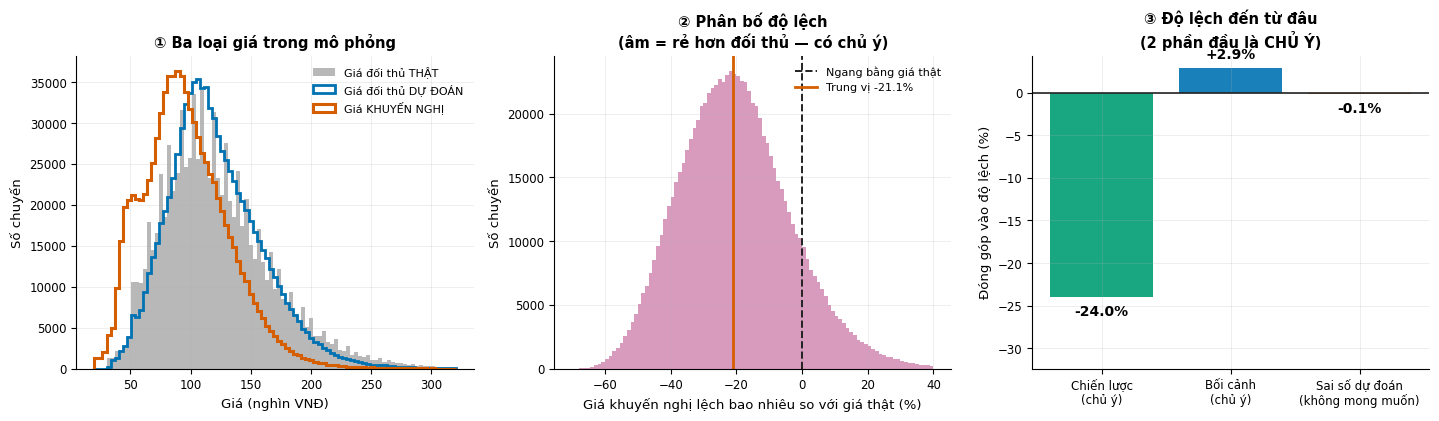

In [5]:
# ===================== HINH E1 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.3))

# --- E1a: phan bo 3 loai gia ---
bins = np.linspace(20, 320, 90)
ax[0].hist(sim.gia_that/1000, bins=bins, color=INK, alpha=0.32, lw=0, label="Giá đối thủ THẬT")
ax[0].hist(sim.gia_dudoan/1000, bins=bins, histtype="step", color=BLUE, lw=2, label="Giá đối thủ DỰ ĐOÁN")
ax[0].hist(sim.gia_khuyennghi/1000, bins=bins, histtype="step", color=RED, lw=2.2, label="Giá KHUYẾN NGHỊ")
ax[0].set_xlabel("Giá (nghìn VNĐ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Ba loại giá trong mô phỏng", fontweight="bold")
ax[0].legend(frameon=False, fontsize=8)

# --- E1b: phan bo do lech ---
ax[1].hist(sim.lech_pct*100, bins=np.linspace(-70, 40, 100), color=PURPLE, alpha=0.75, lw=0)
ax[1].axvline(0, color=INK, lw=1.4, ls="--", label="Ngang bằng giá thật")
ax[1].axvline(sim.lech_pct.median()*100, color=RED, lw=2,
              label=f"Trung vị {sim.lech_pct.median()*100:+.1f}%")
ax[1].set_xlabel("Giá khuyến nghị lệch bao nhiêu so với giá thật (%)")
ax[1].set_ylabel("Số chuyến")
ax[1].set_title("② Phân bố độ lệch\n(âm = rẻ hơn đối thủ — có chủ ý)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# --- E1c: phan ra ---
tp = [(np.exp(sim.tp_chienluoc.mean())-1)*100,
      (np.exp(sim.tp_boicanh.mean())-1)*100,
      (np.exp(sim.tp_saiso.mean())-1)*100]
ten = ["Chiến lược\n(chủ ý)", "Bối cảnh\n(chủ ý)", "Sai số dự đoán\n(không mong muốn)"]
cols_ = [GREEN, BLUE, RED]
b_ = ax[2].bar(range(3), tp, color=cols_, alpha=0.9)
for bb, v in zip(b_, tp):
    off = 1.1 if v >= 0 else -2.2
    ax[2].text(bb.get_x()+bb.get_width()/2, v+off, f"{v:+.1f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[2].axhline(0, color=INK, lw=1.2)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(ten, fontsize=8.5)
ax[2].set_ylabel("Đóng góp vào độ lệch (%)")
ax[2].set_title("③ Độ lệch đến từ đâu\n(2 phần đầu là CHỦ Ý)", fontweight="bold")
ax[2].set_ylim(min(tp)*1.35, max(max(tp)*1.5, 4))

plt.tight_layout(); plt.savefig(HINH / "E1_mo_phong_do_lech.png"); plt.show()

## 4. So sánh các chính sách định giá

Đánh giá **doanh thu kỳ vọng** nếu áp dụng từng chính sách trên toàn bộ tập test.

| Chính sách | Cách đặt giá | Khả thi thực tế? |
|---|---|---|
| **Oracle** | `r* × (1+d) × giá THẬT` | ❌ Không — cần biết trước giá đối thủ |
| **Đề xuất** | `r* × (1+d) × p̂` | ✅ **Có** — chỉ dùng thông tin biết được |
| Bám giá dự đoán | `p̂` | ✅ Có |
| Persistence | giá quan sát gần nhất | ✅ Có |
| Bám giá thật | `giá THẬT` | ❌ Không — chỉ để tham chiếu |

In [6]:
def danh_gia(gia_minh, ten):
    P = P_accept(gia_minh / sim.gia_that, dich=sim.dich_WTP)
    R = gia_minh * P
    return {"Chinh sach": ten,
            "Gia TB (d)": gia_minh.mean(),
            "P(chap nhan) TB": P.mean(),
            "Doanh thu ky vong TB (d)": R.mean()}

ket = pd.DataFrame([
    danh_gia(R_STAR * (1 + sim.dich_WTP) * sim.gia_that,  "1. Oracle (biet truoc gia that)"),
    danh_gia(sim.gia_khuyennghi,                           "2. DE XUAT (dung p_hat)"),
    danh_gia(sim.gia_dudoan,                               "3. Bam gia du doan"),
    danh_gia(sim.persistence,                              "4. Persistence"),
    danh_gia(sim.gia_that,                                 "5. Bam gia that (tham chieu)"),
])
goc = ket.loc[ket["Chinh sach"].str.startswith("5"), "Doanh thu ky vong TB (d)"].iloc[0]
ket["So voi bam gia that"] = (ket["Doanh thu ky vong TB (d)"] / goc - 1) * 100
ket["P(chap nhan) TB"] = (ket["P(chap nhan) TB"] * 100).round(1)
display(ket.round(0))

dt_oracle = ket.iloc[0]["Doanh thu ky vong TB (d)"]
dt_dexuat = ket.iloc[1]["Doanh thu ky vong TB (d)"]
print("=" * 66)
print("CHI PHI CUA VIEC DU DOAN SAI")
print("=" * 66)
print(f"  Oracle (biet truoc gia that) : {dt_oracle:>12,.0f} d/chuyen")
print(f"  De xuat (dung p_hat)         : {dt_dexuat:>12,.0f} d/chuyen")
print(f"  CHENH LECH                   : {dt_oracle - dt_dexuat:>12,.0f} d/chuyen "
      f"({(1 - dt_dexuat/dt_oracle)*100:.2f}%)")
print()
print(f"  -> Day chinh la GIA PHAI TRA cho viec model gia con sai MAE ~18.000d.")
print(f"  -> Neu cai thien model gia, day la phan doanh thu co the lay lai duoc.")

,Chinh sach,Gia TB (d),P(chap nhan) TB,Doanh thu ky vong TB (d),So voi bam gia that
0,1. Oracle (biet truoc gia that),98042.0,75.0,73536.0,10.0
1,2. DE XUAT (dung p_hat),96196.0,73.0,70154.0,5.0
2,3. Bam gia du doan,120688.0,53.0,65176.0,-3.0
3,4. Persistence,122906.0,52.0,60066.0,-10.0
4,5. Bam gia that (tham chieu),122986.0,53.0,66861.0,0.0


CHI PHI CUA VIEC DU DOAN SAI
  Oracle (biet truoc gia that) :       73,536 d/chuyen
  De xuat (dung p_hat)         :       70,154 d/chuyen
  CHENH LECH                   :        3,381 d/chuyen (4.60%)

  -> Day chinh la GIA PHAI TRA cho viec model gia con sai MAE ~18.000d.
  -> Neu cai thien model gia, day la phan doanh thu co the lay lai duoc.


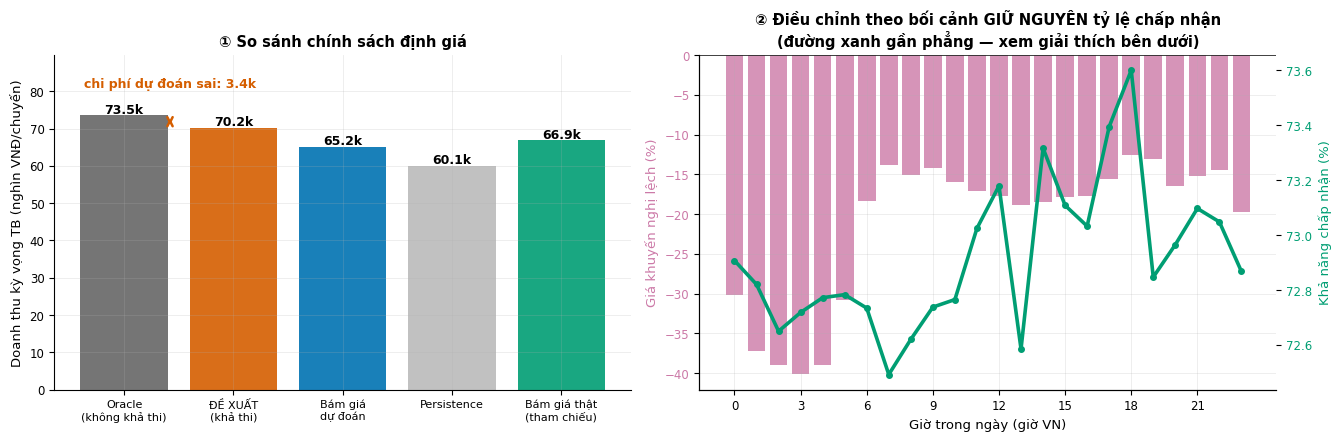

In [7]:
# ===================== HINH E2 =====================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))

ten_cs = ["Oracle\n(không khả thi)", "ĐỀ XUẤT\n(khả thi)", "Bám giá\ndự đoán",
          "Persistence", "Bám giá thật\n(tham chiếu)"]
dt = ket["Doanh thu ky vong TB (d)"].values / 1000
mau = [MUT, RED, BLUE, "#BBBBBB", GREEN]
b_ = ax[0].bar(range(5), dt, color=mau, alpha=0.9)
for bb, v in zip(b_, dt):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+0.6, f"{v:.1f}k", ha="center",
               fontsize=9, fontweight="bold")
# danh dau chenh lech oracle vs de xuat
ax[0].annotate("", xy=(0.42, dt[1]), xytext=(0.42, dt[0]),
               arrowprops=dict(arrowstyle="<->", color=RED, lw=1.8))
ax[0].text(0.42, dt[0]*1.10, f"chi phí dự đoán sai: {(dt[0]-dt[1]):.1f}k",
           fontsize=9, fontweight="bold", color=RED, ha="center")
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(ten_cs, fontsize=8)
ax[0].set_ylabel("Doanh thu kỳ vọng TB (nghìn VNĐ/chuyến)")
ax[0].set_title("① So sánh chính sách định giá", fontweight="bold")
ax[0].set_ylim(0, max(dt)*1.22)

# --- do lech theo gio ---
g = sim.groupby("gio")
lech_gio = g.lech_pct.mean()*100
P_gio = g.P_chapnhan.mean()*100
a2 = ax[1]
a2.bar(lech_gio.index, lech_gio.values, color=PURPLE, alpha=0.8, label="Độ lệch giá (%)")
a2.axhline(0, color=INK, lw=1.2)
a2.set_xlabel("Giờ trong ngày (giờ VN)"); a2.set_ylabel("Giá khuyến nghị lệch (%)", color=PURPLE)
a2.tick_params(axis="y", labelcolor=PURPLE)
a2.set_xticks(range(0, 24, 3))
a3 = a2.twinx()
a3.plot(P_gio.index, P_gio.values, color=GREEN, lw=2.6, marker="o", ms=4, label="P(chấp nhận)")
a3.set_ylabel("Khả năng chấp nhận (%)", color=GREEN)
a3.tick_params(axis="y", labelcolor=GREEN); a3.grid(False)
a2.set_title("② Điều chỉnh theo bối cảnh GIỮ NGUYÊN tỷ lệ chấp nhận\n(đường xanh gần phẳng — xem giải thích bên dưới)",
             fontweight="bold")

plt.tight_layout(); plt.savefig(HINH / "E2_so_sanh_chinh_sach.png"); plt.show()

### ⭐ Vì sao tỷ lệ chấp nhận gần như PHẲNG theo giờ?

Đường xanh ở hình E2② chỉ dao động **72,6% – 73,6%** — gần như không đổi dù giờ cao điểm hay đêm
khuya. Đây **không phải lỗi**, mà là kết quả toán học:

$$P = \sigma\Big(a + b\big[\log\tfrac{p^*}{p_{\text{thật}}} - \log(1+d)\big]\Big),
\qquad p^* = r^*(1+d)\,\hat{p}$$

Thay vào:

$$\log\tfrac{p^*}{p_{\text{thật}}} - \log(1+d)
= \log r^* + \cancel{\log(1+d)} + \log\tfrac{\hat p}{p_{\text{thật}}} - \cancel{\log(1+d)}
= \log r^* + \log\tfrac{\hat p}{p_{\text{thật}}}$$

**Số hạng bối cảnh $(1+d)$ triệt tiêu hoàn toàn.**

**Ý nghĩa vận hành:** khi nâng giá đúng bằng mức dịch chuyển WTP, ta **thu thêm tiền mà không mất
khách**. Giờ cao điểm khách chịu chi hơn 12% → mình tăng giá 12% → tỷ lệ chấp nhận giữ nguyên,
doanh thu tăng 12%.

Phần dao động nhỏ còn lại (~1 điểm %) **chỉ đến từ sai số dự đoán** $\hat p / p_{\text{thật}}$ khác
nhau theo giờ — tức là dấu vết của model giá, không phải của bối cảnh.

---

## 5. Ví dụ cụ thể — chạy pipeline cho vài chuyến

In [8]:
mau = sim.sample(6, random_state=42).copy()
bang = pd.DataFrame({
    "Gio": mau.gio.values,
    "Thoi tiet": np.where(mau.mua.values, "Mua", "Khong mua"),
    "① Gia doi thu THAT": mau.gia_that.values.round(0),
    "② Gia DU DOAN (p_hat)": mau.gia_dudoan.values.round(0),
    "③ Dich WTP": (mau.dich_WTP.values*100).round(1),
    "④ Gia KHUYEN NGHI": mau.gia_khuyennghi.values.round(0),
    "⑤ P(chap nhan) %": (mau.P_chapnhan.values*100).round(1),
    "⑥ Doanh thu ky vong": mau.doanhthu_kyvong.values.round(0),
    "Lech vs gia that %": (mau.lech_pct.values*100).round(1),
})
display(bang)

r0 = mau.iloc[0]
print("=" * 68)
print("GIAI THICH CHI TIET CHUYEN DAU TIEN")
print("=" * 68)
print(f"  Boi canh          : gio {int(r0.gio)}h, {'co mua' if r0.mua else 'khong mua'}")
print(f"  Dich WTP          : {r0.dich_WTP*100:+.1f}%")
print()
print(f"  ① Doi thu bao THAT: {r0.gia_that:>10,.0f} d   <- luc quyet dinh CHUA BIET")
print(f"  ② Model du doan   : {r0.gia_dudoan:>10,.0f} d   <- dung cai nay de quyet dinh")
print(f"  ③ Ty le toi uu    : {R_STAR:>10.3f}")
print(f"  ④ Gia khuyen nghi : {R_STAR:.3f} x (1{r0.dich_WTP:+.3f}) x {r0.gia_dudoan:,.0f} "
      f"= {r0.gia_khuyennghi:,.0f} d")
print()
print(f"  ⑤ Khach so {r0.gia_khuyennghi:,.0f} voi gia THAT {r0.gia_that:,.0f} "
      f"-> ty le {r0.gia_khuyennghi/r0.gia_that:.3f}")
print(f"     => P(chap nhan) = {r0.P_chapnhan*100:.1f}%")
print(f"  ⑥ Doanh thu ky vong = {r0.gia_khuyennghi:,.0f} x {r0.P_chapnhan:.3f} "
      f"= {r0.doanhthu_kyvong:,.0f} d")

,Gio,Thoi tiet,① Gia doi thu THAT,② Gia DU DOAN (p_hat),③ Dich WTP,④ Gia KHUYEN NGHI,⑤ P(chap nhan) %,⑥ Doanh thu ky vong,Lech vs gia that %
0,9,Khong mua,118000.0,113507.0,9.3,94254.0,77.8,73331.0,-20.1
1,4,Khong mua,57000.0,77104.0,-23.3,44936.0,47.3,21238.0,-21.2
2,0,Mua,145000.0,120789.0,-6.7,85645.0,86.2,73802.0,-40.9
3,17,Khong mua,107000.0,173514.0,8.3,142714.0,30.3,43188.0,33.4
4,14,Mua,145000.0,103538.0,9.3,85996.0,92.0,79139.0,-40.7
5,19,Khong mua,215000.0,199309.0,10.3,167048.0,80.2,134056.0,-22.3


GIAI THICH CHI TIET CHUYEN DAU TIEN
  Boi canh          : gio 9h, khong mua
  Dich WTP          : +9.3%

  ① Doi thu bao THAT:    118,000 d   <- luc quyet dinh CHUA BIET
  ② Model du doan   :    113,507 d   <- dung cai nay de quyet dinh
  ③ Ty le toi uu    :      0.760
  ④ Gia khuyen nghi : 0.760 x (1+0.093) x 113,507 = 94,254 d

  ⑤ Khach so 94,254 voi gia THAT 118,000 -> ty le 0.799
     => P(chap nhan) = 77.8%
  ⑥ Doanh thu ky vong = 94,254 x 0.778 = 73,331 d


## 6. Độ nhạy — kết quả đổi thế nào khi đổi giả định elasticity?

In [9]:
rows = []
for e in EPS_DAI:
    r_s = ty_le_toi_uu(e)
    gia_kn = r_s * (1 + sim.dich_WTP) * sim.gia_dudoan
    P = P_accept(gia_kn / sim.gia_that, eps=e, dich=sim.dich_WTP)
    R = gia_kn * P
    # oracle tuong ung
    gia_or = r_s * (1 + sim.dich_WTP) * sim.gia_that
    R_or = gia_or * P_accept(gia_or / sim.gia_that, eps=e, dich=sim.dich_WTP)
    rows.append({
        "elasticity": e,
        "ty_le_toi_uu": round(r_s, 3),
        "gia_khuyen_nghi_TB": round(gia_kn.mean()),
        "lech_vs_gia_that_%": round((gia_kn/sim.gia_that - 1).mean()*100, 1),
        "P(chap nhan)_%": round(P.mean()*100, 1),
        "doanh_thu_TB": round(R.mean()),
        "chi_phi_du_doan_sai_%": round((1 - R.mean()/R_or.mean())*100, 2),
    })
ds = pd.DataFrame(rows)
display(ds)

print("TINH VUNG:")
print(f"  - Gia khuyen nghi LUON thap hon gia that : "
      f"{(ds['lech_vs_gia_that_%'] < 0).sum()}/{len(ds)} truong hop")
print(f"  - Chi phi du doan sai dao dong           : "
      f"{ds['chi_phi_du_doan_sai_%'].min():.2f}% - {ds['chi_phi_du_doan_sai_%'].max():.2f}%")

,elasticity,ty_le_toi_uu,gia_khuyen_nghi_TB,lech_vs_gia_that_%,P(chap nhan)_%,doanh_thu_TB,chi_phi_du_doan_sai_%
0,-1.2,0.869,110063,-8.6,58.0,63900,2.33
1,-2.0,0.760,96196,-20.1,72.9,70154,4.60
2,-3.0,0.765,96804,-19.6,78.9,76344,7.16


TINH VUNG:
  - Gia khuyen nghi LUON thap hon gia that : 3/3 truong hop
  - Chi phi du doan sai dao dong           : 2.33% - 7.16%


## 7. Kết luận

### Trả lời câu hỏi: giá khuyến nghị lệch bao nhiêu so với giá thật?

Độ lệch **không phải sai số** — nó gồm 3 phần, trong đó **2 phần là chủ ý**:

| Thành phần | Bản chất | Diễn giải |
|---|---|---|
| **Chiến lược** | ✅ Chủ ý | Model khuyến nghị bán rẻ hơn để giành khách từ đối thủ |
| **Bối cảnh** | ✅ Chủ ý | Giờ cao điểm / trời mưa → nâng giá lên vì khách dễ chấp nhận hơn |
| **Sai số dự đoán** | ⚠️ Không mong muốn | Do model giá còn sai — phần duy nhất cần cải thiện |

### Chi phí của việc dự đoán sai

So sánh **Oracle** (giả sử biết trước giá đối thủ) với **Đề xuất** (chỉ dùng `p̂`) cho ra con số cụ
thể: mỗi chuyến mất bao nhiêu đồng doanh thu kỳ vọng vì model giá chưa hoàn hảo.

→ Đây là **giá trị kinh tế của việc cải thiện model giá**, quy đổi trực tiếp ra tiền. Nếu giảm được
MAE thì lấy lại được đúng phần này.

### ⚠️ Giới hạn phải nêu rõ khi báo cáo

| Giới hạn | Chi tiết |
|---|---|
| **Doanh thu kỳ vọng là mô phỏng** | Tính theo `P(chấp nhận)` giả định, **không phải doanh thu thật** |
| **Chưa kiểm chứng thực nghiệm** | Không có nhãn accept/reject để đối chiếu |
| **`P₀ = 0,5` là quy ước** | Con số tuyệt đối phụ thuộc giả định này |
| **Model tĩnh** | Chưa tính phản ứng của đối thủ khi mình giảm giá |
| **Không cá nhân hoá** | Một đường cong chung cho mọi khách |

> **Cách phát biểu đúng:** *"Dưới giả định elasticity ε ∈ [−1,2; −3,0], chính sách định giá đề xuất
> cho doanh thu kỳ vọng cao hơn X% so với bám giá đối thủ, và chi phí do model giá chưa hoàn hảo là
> Y% doanh thu."* — luôn kèm mệnh đề *"dưới giả định"*.